In [1]:
import numpy as np
from iminuit import Minuit
from iminuit.cost import ExtendedBinnedNLL
from scipy.stats import expon, norm
import matplotlib.pyplot as plt

def dataset_splitter(data: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    data = data.T
    discriminator = np.array([bool(i) for i in data[1]])

    data_g = data[0][discriminator]
    data_p = data[0][~discriminator]
    return data_g, data_p


In [2]:


# void datasets
data_0 = np.genfromtxt("Data/timestamp/21_01_2024_17_42.csv", delimiter=',')
data_1 = np.genfromtxt("Data/timestamp/23_01_2026_17_31.csv", delimiter=',')
data_2 = np.genfromtxt("Data/timestamp/29_01_2026_17_20.csv", delimiter=',')
data_3 = np.genfromtxt("Data/timestamp/02_02_2026_17_14.csv", delimiter=',')
data_4 = np.genfromtxt("Data/timestamp/05_02_2026_18_17.csv", delimiter=',')
data_5 = np.genfromtxt("Data/timestamp/11_02_2026_17_52.csv", delimiter=',')
data_6 = np.genfromtxt("Data/timestamp/16_02_2026_12_25.csv", delimiter=',')
data_7 = np.genfromtxt("Data/timestamp/20_02_2026_15_57.csv", delimiter=',')
inv_data_1 = np.genfromtxt("Data/timestamp/inverted_26_02_2026_16_57.csv" , delimiter=',')
mult_data_1 = np.genfromtxt("Data/timestamp/triple_04_03_2026_05_12.csv",delimiter=",")
mult_data_2 = np.genfromtxt("Data/timestamp/triple_06_03_2026_14_12.csv" , delimiter=",")
mult_data_3 = np.genfromtxt("Data/timestamp/triple_delay_16_03_2026_14_17.csv" , delimiter=",")
mult_data_4 = np.genfromtxt("Data/timestamp/triple_delay_20_03_2026_14_27.csv" , delimiter=",")


data_g_1 , data_p_1 = dataset_splitter( mult_data_1)
data_g_2 , data_p_2 = dataset_splitter( mult_data_2)
data_g_3 , data_p_3 = dataset_splitter( mult_data_3)
data_g_4 , data_p_4 = dataset_splitter( mult_data_4)


data_g = np.concatenate((data_g_1, data_g_2 , data_g_3 , data_g_4))
data_p = np.concatenate( (data_p_1 , data_p_2 , data_p_3 , data_p_4))


data = np.concatenate((data_0, data_1, data_2, data_3, data_4, data_5, data_6, data_7, data_g, data_p , inv_data_1))


data_refact:np.ndarray = data[(data > 0.2e-6)&(data < 7.2e-6)]## forse si può anche non tagliare dal basso
data_refact_rescaled = data_refact *1e6



Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END ....................................bandwidth=1e-08; total time=  46.0s
[CV] END ...................bandwidth=1.2000000000000002e-07; total time= 1.1min
[CV] END ...................bandwidth=1.2000000000000002e-07; total time= 1.1min
[CV] END ...................bandwidth=1.2000000000000002e-07; total time= 1.2min
[CV] END ...................bandwidth=1.2000000000000002e-07; total time= 1.5min
[CV] END ...................bandwidth=2.3000000000000002e-07; total time= 1.5min
[CV] END ...................bandwidth=1.2000000000000002e-07; total time= 1.5min
[CV] END ...................bandwidth=2.3000000000000002e-07; total time= 1.5min
[CV] END ...................bandwidth=2.3000000000000002e-07; total time= 1.3min
[CV] END ....................................bandwidth=1e-08; total time= 2.2min
[CV] END ....................................bandwidth=1e-08; total time= 2.2min
[CV] END ....................................ban

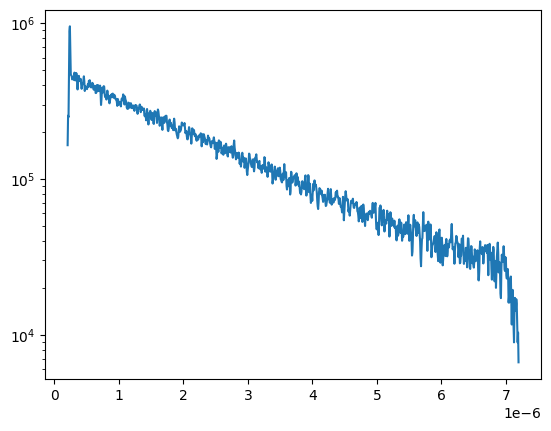

In [15]:
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

bandwidths = np.linspace(1e-8, 1e-6, 10)
grid = GridSearchCV(KernelDensity(), {'bandwidth': bandwidths}, n_jobs = -1, verbose = 2)
grid.fit(data_refact[:, np.newaxis])
best = grid.best_params_['bandwidth']

xgrid = np.linspace(data_refact.min(),data_refact.max(),1000)

def kde_sklearn(data_refact, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data_refact[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFtophat = kde_sklearn(data_refact ,bandwidth=best, kernel="epanechnikov") 
plt.plot(xgrid,PDFtophat)
plt.yscale('log')
print(PDFtophat.max())



In [14]:
print (best)

1e-09


In [10]:
from sklearn.cluster import MeanShift, estimate_bandwidth

estimate_band = estimate_bandwidth(data_refact[:, np.newaxis], quantile=0.2)
ms = MeanShift(bandwidth= estimate_band, cluster_all = True, n_jobs = -1)
ms_labels = ms.fit_predict(data_refact[:, np.newaxis])

In [11]:
ms_labels

array([0, 0, 0, ..., 0, 0, 0], shape=(80707,))

In [12]:
ms_labels[ms_labels == 1]

array([], dtype=int64)

non divide signal from background as expected...

In [ ]:
print(np.where(PDFtophat == PDFtophat.max()))
nd = np.sort(data)
print(nd[45])

(array([13]),)
1.2e-08


# emcee try

For an experiment active between $t_{min}$ and $t_{max}$, the log-likelihood is determined by summing the log of your model rate at every data point, and then subtracting the total expected number of events ($N_{exp}$) over that time window so the amplitude parameters scale correctly.Mathematically, the extended log-likelihood $\log \mathcal{L}$ is:$$\log \mathcal{L} = \sum_{i=1}^{N} \log(a e^{-\alpha t_i} + b) - N_{exp}$$Where the expected number of events is the integral of your model from $t_{min}$ to $t_{max}$:$$N_{exp} = \int_{t_{min}}^{t_{max}} (a e^{-\alpha t} + b) \, dt = \frac{a}{\alpha} \left( e^{-\alpha t_{min}} - e^{-\alpha t_{max}} \right) + b(t_{max} - t_{min})$$

In [3]:
import emcee
import numpy as np
import scipy.stats as stats
import corner
import matplotlib.pyplot as plt
t_min = data_refact_rescaled.min()
t_max = data_refact_rescaled.max()

In [6]:

# cose per emcee
ndim = 3
nwalkers = 32
nsteps = 500000
burn = 30000

#credo che in principio io possa esprimere il tutto solo in base a -log(alpha) poichè è l'unico che varia davvero,
#in teoria MCMC non tengono conto dei prior uniformi

def log_prior(theta):
    a, b, tau = theta
    
    # Dramatically loosen the bounds. 
    # 'a' is a rate amplitude, so it can easily be in the millions depending on units.
    max_a = 1e7 
    max_b = 1e6
    
    if not (0 < a <= max_a and 0 < b <= max_b and 0.1 <= tau <= 20.0):
        return -np.inf # Outside bounds means zero probability -> log is -inf
        
    return -np.log(tau)

def myLogPosterior(theta, times, t_min, t_max):
    a, b, (tau) = theta  # Kept (1/tau) consistent here
    
    # 1. Check priors first to save execution time
    log_p = log_prior(theta)
    if np.isinf(log_p):
        return -np.inf
    
    # 2. Calculate the integrated expected number of events (N_exp)
    # This acts as the normalization factor for your amplitudes
    N_exp = (a * tau) * (np.exp(-(1/tau) * t_min) - np.exp(-(1/tau) * t_max)) + b * (t_max - t_min)
    
    # 3. Calculate Unbinned Log-Likelihood
    # Sum of log(model) at every observed muon decay time
    model_vals = b + a * np.exp(-(1/tau) * times)
    
    # Protection against negative values inside the log 
    if np.any(model_vals <= 0):
        return -np.inf
        
    log_likelihood = np.sum(np.log(model_vals)) - N_exp
    
    return log_likelihood + log_p

from scipy.optimize import minimize

# 1. Define the NEGATIVE log posterior (since optimizers minimize things)
def neg_log_posterior(theta, times, t_min, t_max):
    log_post = myLogPosterior(theta, times, t_min, t_max)
    if np.isinf(log_post):
        return 1e100 # Return a massive number instead of inf
    return -log_post

# 2. Run a quick, rough optimization to find the peak coordinates
initial_guess = [300000, 10000, 2.2] 

print("Finding the posterior peak...")
res = minimize(neg_log_posterior, initial_guess, args=(data_refact_rescaled, t_min, t_max), method='Nelder-Mead')
best_a, best_b, best_tau = res.x
print(f"Peak found at: a={best_a:.1f}, b={best_b:.1f}, tau={best_tau:.3f}")

# 3. Initialize your walkers in a MICROSCOPIC ball around the peak
# We use a 0.1% (1e-3) or 1% standard deviation so they don't fall off the cliff
starting_guesses = np.zeros((nwalkers, ndim))
starting_guesses[:, 0] = best_a + 1e-3 * best_a * np.random.randn(nwalkers)
starting_guesses[:, 1] = best_b + 1e-3 * best_b * np.random.randn(nwalkers)
starting_guesses[:, 2] = best_tau + 1e-3 * best_tau * np.random.randn(nwalkers)
print("--- DIAGNOSTIC CHECK ---")
print(f"Optimizer success: {res.success}")
print(f"Peak values found: a={best_a:.2f}, b={best_b:.2f}, tau={best_tau:.5f}")

# Check the log-likelihood exactly at the peak
peak_lp = myLogPosterior([best_a, best_b, best_tau], data_refact_rescaled, t_min, t_max)
print(f"Log-probability at exact peak: {peak_lp}")

# Check the log-likelihood of your first 3 walkers
for i in range(3):
    lp = myLogPosterior(starting_guesses[i], data_refact_rescaled, t_min, t_max)
    print(f"Walker {i} starting log-prob: {lp}")
print("------------------------")

# 4. Now run your sampler safely
sampler = emcee.EnsembleSampler(nwalkers, ndim, myLogPosterior, args=(data_refact_rescaled, t_min, t_max))
sampler.run_mcmc(starting_guesses, nsteps, progress=True)

 
# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape:
emcee_trace  = sampler.get_chain(discard = burn, flat = True)




Finding the posterior peak...
Peak found at: a=41038.8, b=625.0, tau=2.127
--- DIAGNOSTIC CHECK ---
Optimizer success: False
Peak values found: a=41038.82, b=625.04, tau=2.12655
Log-probability at exact peak: 699698.2626852632
Walker 0 starting log-prob: 699698.1878475407
Walker 1 starting log-prob: 699698.2562260482
Walker 2 starting log-prob: 699698.2421093304
------------------------


100%|██████████| 500000/500000 [3:36:18<00:00, 38.52it/s]  


In [7]:
print("Acceptance fraction per walker:")
print(sampler.acceptance_fraction)

Acceptance fraction per walker:
[0.645978 0.648102 0.645544 0.646904 0.64719  0.646402 0.647268 0.646768
 0.645582 0.647188 0.647426 0.647678 0.645984 0.646694 0.647164 0.646782
 0.647862 0.645614 0.647176 0.646548 0.645924 0.647122 0.646616 0.646796
 0.646666 0.646138 0.646976 0.645864 0.647032 0.64704  0.645806 0.646724]


In [8]:
print(sampler.chain.shape) #chain structure: 16 walkers, 100000 steps, 4 variables
print(len(emcee_trace.flatten()))
tau = sampler.get_autocorr_time()
print(tau)
thin = np.max([int(x + 1) for x in tau]) #il thinning deve avvenire con una sola autocorrelation lenght
emcee_trace1 = sampler.get_chain(discard = burn, thin = thin, flat = True)
print(emcee_trace.shape)

(32, 500000, 3)
45120000
[40.24331956 40.01599344 40.07840671]
(15040000, 3)


Text(0.5, 1.0, 'tau posterior')

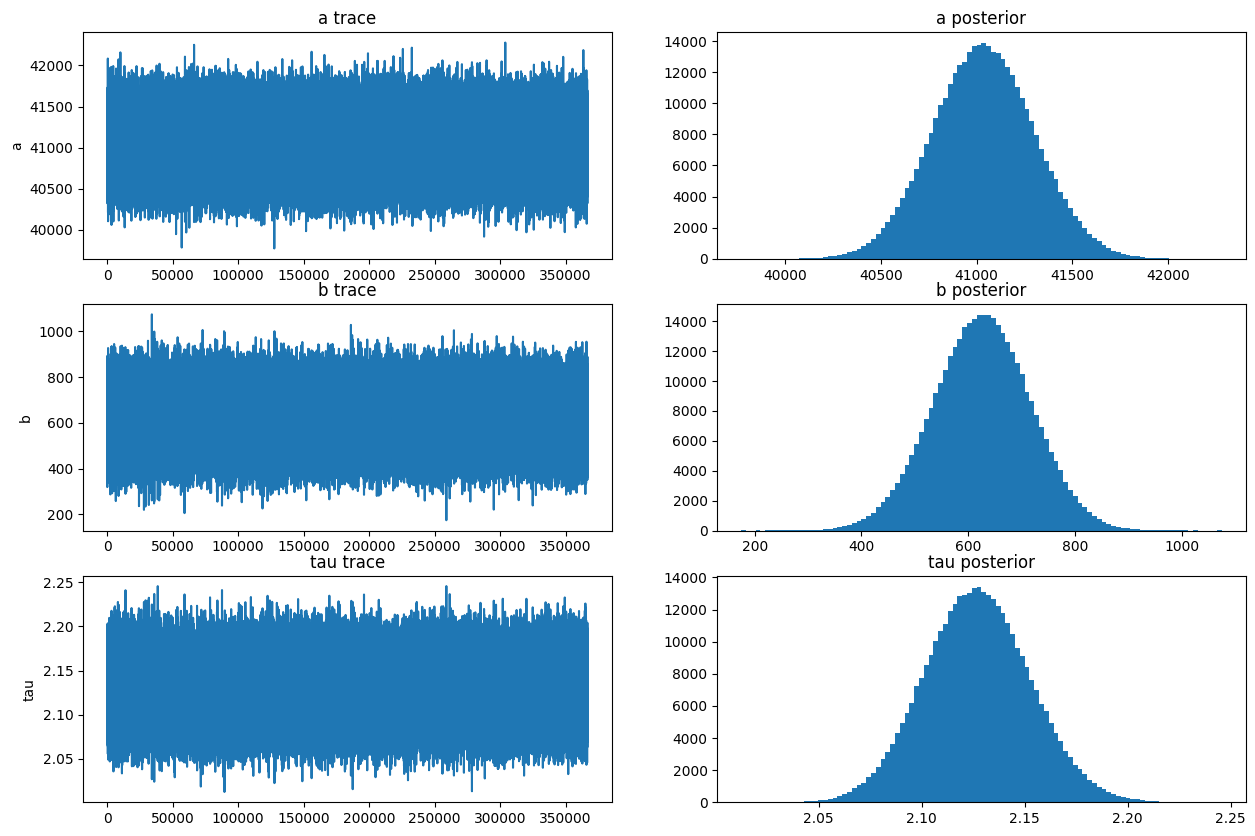

In [9]:
a = emcee_trace1[:, 0]
b = emcee_trace1[:, 1]
tau = emcee_trace1[:, 2]
fig, ax = plt.subplots(figsize = (15, 10), ncols = 2, nrows = 3)
ax[0, 0].plot(np.arange(len(a)), a)
ax[0, 0].set_title("a trace")
ax[0, 0].set_ylabel("a")
ax[0, 1].hist(a, bins=100)
ax[0, 1].set_title("a posterior")

ax[1, 0].plot(np.arange(len(b)), b)
ax[1, 0].set_title("b trace")
ax[1, 0].set_ylabel("b")
ax[1, 1].hist(b, bins=100)
ax[1, 1].set_title("b posterior")

ax[2, 0].plot(np.arange(len(tau)), tau)
ax[2, 0].set_title("tau trace")
ax[2, 0].set_ylabel("tau")
ax[2, 1].hist(tau, bins=100)
ax[2, 1].set_title("tau posterior")

In [10]:

# 2. Extract the chains (assuming emcee_trace1 contains your samples)
a_samples = emcee_trace1[:, 0]
b_samples = emcee_trace1[:, 1]
tau_samples = emcee_trace1[:, 2]

# 3. Compute N_sig and N_bg for every single MCMC step
N_bg_samples = b_samples * (t_max - t_min)
N_sig_samples = a_samples * tau_samples * (np.exp(-t_min / tau_samples) - np.exp(-t_max / tau_samples))
N_total_samples = N_sig_samples + N_bg_samples

# 4. Compute the fractions for every step
f_sig_samples = N_sig_samples / N_total_samples
f_bg_samples = N_bg_samples / N_total_samples

# 5. Print the mean results and 1-sigma uncertainties
print(f"Signal Fraction:     {np.mean(f_sig_samples)*100:.2f}% ± {np.std(f_sig_samples)*100:.2f}%")
print(f"Background Fraction: {np.mean(f_bg_samples)*100:.2f}% ± {np.std(f_bg_samples)*100:.2f}%")

Signal Fraction:     94.58% ± 0.79%
Background Fraction: 5.42% ± 0.79%


In [11]:
# 1. Name the file where you want to store your results
archive_filename = "muon_lifetime_mcmc_traces.npy"

# 2. Save the trace array (assuming it is named emcee_trace1)
np.save(archive_filename, emcee_trace1)
print(f"🎉 Traces successfully frozen into '{archive_filename}'!")
print(f"Array shape saved: {emcee_trace1.shape}")

# =====================================================================
# HOW TO RELOAD THIS LATER (Paste this into a new cell after a restart)
# =====================================================================
# import numpy as np
# import matplotlib.pyplot as plt
# 
# # Load the raw data back into memory
# loaded_trace = np.load("muon_lifetime_mcmc_traces.npy")
# 
# # Unpack your parameters exactly like before
# a = loaded_trace[:, 0]
# b = loaded_trace[:, 1]
# tau = loaded_trace[:, 2]
# 
# print("Traces reloaded successfully! Ready for analysis.")

🎉 Traces successfully frozen into 'muon_lifetime_mcmc_traces.npy'!
Array shape saved: (366816, 3)
